<h1 style="text-align: center; color: darkblue;">EDA and Quick Prototyping</h1>

### 📑 <font color='blue'> Table of Contents </font>
1. [Introduction](#1)
2. [Setup](#2)
3. [Load best run and artifacs](#3)
4. [Results and visualization](#4)
5. [Inference](#5)

## <a id="1" style="color: darkred; text-decoration: none;">1. Introduction</a>

In this notebook, we explore Industrial Control System (ICS) network traffic data with the goal of understanding its structure and behavior. We’ll perform Exploratory Data Analysis (EDA) to identify key patterns, relationships, and potential challenges within the dataset — such as class imbalance or feature correlations.

After gaining insights from the data, we’ll move into quick prototyping by training a few simple supervised models to classify network traffic into categories such as benign, DoS, DoS Hulk, and others.

The objective here is not to build the most accurate model, but to:

- Develop an initial understanding of the data.

- Identify which features or preprocessing steps might be useful.

- Evaluate baseline models to guide future, more sophisticated experiments.

This notebook serves as a foundation for deeper modeling and optimization later in the pipeline.

## <a id="2" style="color: darkred; text-decoration: none;"> 2.Setup </a>

In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [37]:
pd.set_option("display.max_rows", None)       # show all rows
pd.set_option("display.max_columns", None)    # show all columns
pd.set_option("display.width", None)          # don't wrap lines
pd.set_option("display.max_colwidth", None)   # show full cell content

## <a id="3" style="color: darkred; text-decoration: none;"> 3. Loading and inspecting data </a>

Given the restricted resources and the fact that this is a portfolio project, I will use a subset of the ICS Dataset

The CICIDS2017 dataset consists of labeled network flows, including full packet payloads in pcap format, the corresponding profiles and the labeled flows (GeneratedLabelledFlows.zip) and CSV files for machine and deep learning purpose (MachineLearningCSV.zip) are publicly available for researchers. [Link](https://www.unb.ca/cic/datasets/ids-2017.html)

Iman Sharafaldin, Arash Habibi Lashkari, and Ali A. Ghorbani, “Toward Generating a New Intrusion Detection Dataset and Intrusion Traffic Characterization”, 4th International Conference on Information Systems Security and Privacy (ICISSP), Portugal, January 2018.


In [38]:
df = pd.read_csv("../data/data.csv", encoding="latin1")
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,61900,54,2,2,4,12,2,2,2.000000,0.000000,6,6,6.000000,0.000000,296296.296300,74074.074070,1.800000e+01,2.605763e+01,48,1,1,1.00,0.000000e+00,1,1,48,48.0,0.000000e+00,48,48,0,0,0,0,48,40,37037.037040,37037.037040,2,6,3.600000,2.190890,4.800,0,0,0,1,0,0,0,0,1,4.500000,2.000000,6.000000,48,0,0,0,0,0,0,2,4,2,12,1024,0,1,24,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,24800,49,2,0,4,0,2,2,2.000000,0.000000,0,0,0.000000,0.000000,81632.653060,40816.326530,4.900000e+01,0.000000e+00,49,49,49,49.00,0.000000e+00,49,49,0,0.0,0.000000e+00,0,0,0,0,0,0,48,0,40816.326530,0.000000,2,2,2.000000,0.000000,0.000,0,0,0,1,0,0,0,0,0,3.000000,2.000000,0.000000,48,0,0,0,0,0,0,2,4,0,0,1024,-1,1,24,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,443,5885346,9,6,710,3826,517,0,78.888889,172.656773,1448,0,637.666667,672.176663,770.727838,2.548703,4.203819e+05,1.489591e+06,5592381,2,5885346,735668.25,1.963602e+06,5592381,16,268090,53618.0,1.008750e+05,232654,191,0,0,0,0,296,200,1.529222,1.019481,0,1448,283.500000,497.149072,247157.200,0,0,0,1,0,0,0,0,0,302.400000,78.888889,637.666667,296,0,0,0,0,0,0,9,710,6,3826,29200,65,3,32,292949.0,0.0,292949,292949,5592381.0,0.0,5592381,5592381,BENIGN
3,49738,57,1,1,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,35087.719298,5.700000e+01,0.000000e+00,57,57,0,0.00,0.000000e+00,0,0,0,0.0,0.000000e+00,0,0,0,0,0,0,32,32,17543.859649,17543.859649,0,0,0.000000,0.000000,0.000,0,0,0,0,1,1,0,0,1,0.000000,0.000000,0.000000,32,0,0,0,0,0,0,1,0,1,0,332,229,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,80,98306933,6,7,363,11595,345,0,60.500000,139.406958,4355,0,1656.428571,2121.983652,121.639437,0.132239,8.192244e+06,2.840000e+07,98300000,3,98300000,19700000.00,4.400000e+07,98300000,990,98300000,16400000.0,4.010000e+07,98300000,15,0,0,0,0,164,232,0.061033,0.071206,0,4355,854.571429,1666.831481,2778327.187,1,0,0,0,0,0,0,0,1,920.307692,60.500000,1656.428571,164,0,0,0,0,0,0,6,363,7,11595,0,235,3,20,14018.0,0.0,14018,14018,98300000.0,0.0,98300000,98300000,DoS Hulk


In [5]:
df.shape

(79998, 79)

In [52]:
# basic summary
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "unique": df.nunique(),
})

print(summary.to_string())



                               dtype  missing  unique
Destination Port               int64        0   10832
Flow Duration                  int64        0   44162
Total Fwd Packets              int64        0     286
Total Backward Packets         int64        0     339
Total Length of Fwd Packets    int64        0    3823
Total Length of Bwd Packets    int64        0    7091
Fwd Packet Length Max          int64        0    1951
Fwd Packet Length Min          int64        0     152
Fwd Packet Length Mean       float64        0    8630
Fwd Packet Length Std        float64        0   12967
Bwd Packet Length Max          int64        0    2119
Bwd Packet Length Min          int64        0     346
Bwd Packet Length Mean       float64        0    9577
Bwd Packet Length Std        float64        0   11191
Flow Bytes/s                 float64       38   54486
Flow Packets/s               float64        0   47913
Flow IAT Mean                float64        0   46201
Flow IAT Std                

**Handle duplicates**

In [7]:
print("Number of Duplicates:", df.duplicated().sum())

# drop duplicates
df = df.drop_duplicates()
df = df.dropna()

print("Sanity check:", df.duplicated().sum())

Number of Duplicates: 2649
Sanity check: 0


**Handle infinities**

In [8]:
print("Infinities:", np.isinf(df.select_dtypes(include=[np.number])).any().any())

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()

print("Sanity check:", np.isinf(df.select_dtypes(include=[np.number])).any().any())


Infinities: True
Sanity check: False


**Handle missing values (NaN, None..)**

In [10]:
# Count NaNs per column
print(df.isna().sum())

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
Bwd Packet Length Mean         0
Bwd Packet Length Std          0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Mean                  0
Flow IAT Std                   0
Flow IAT Max                   0
Flow IAT Min                   0
Fwd IAT Total                  0
Fwd IAT Mean                   0
Fwd IAT Std                    0
Fwd IAT Max                    0
Fwd IAT Min                    0
Bwd IAT Total                  0
Bwd IAT Mean                   0
Bwd IAT Std                    0
Bwd IAT Max                    0
Bwd IAT Min                    0
Fwd PSH Fl

There are no missing values, but if there were, I could, for ecxample, drop columns with more than 50% missing values.

```
threshold = 0.5
df = df.loc[:, df.isna().mean() < threshold]
```

**Label distribution**

In [11]:
# Count rows per class
label_counts = df['Label'].value_counts()
print("\033[1mLabel counts\n\033[0m\n", label_counts)


print("--------------------------------------\n")

# Percentage of each class
label_percent = df['Label'].value_counts(normalize=True) * 100
print("\033[1mLabel counts (%)\n\033[0m\n", label_percent)

Label counts

 BENIGN                        63101
DoS Hulk                       5162
PortScan                       4373
DDoS                           3618
DoS GoldenEye                   291
FTP-Patator                     189
DoS slowloris                   162
DoS Slowhttptest                155
SSH-Patator                     138
Bot                              54
Web Attack ï¿½ Brute Force       43
Web Attack ï¿½ XSS               19
Name: Label, dtype: int64
--------------------------------------

Label counts (%)

 BENIGN                        81.626027
DoS Hulk                       6.677446
PortScan                       5.656814
DDoS                           4.680163
DoS GoldenEye                  0.376431
FTP-Patator                    0.244486
DoS slowloris                  0.209560
DoS Slowhttptest               0.200504
SSH-Patator                    0.178514
Bot                            0.069853
Web Attack ï¿½ Brute Force     0.055624
Web Attack ï¿½ XSS          

The dataset is highly imbalanced: BENIGN traffic dominates with over 81%, followed by DoS Hulk (6.7%), PortScan (5.7%), and DDoS (4.7%). The remaining classes each represent less than 0.4% of the data, indicating they are extremely underrepresented.

Classes such as Bot, Web Attack – Brute Force, and Web Attack – XSS account for less than 0.1% each. These are rare events, making it difficult for a model to learn meaningful patterns from so few samples.
To improve class balance and ensure more reliable learning, I’ll merge them into a single “Rare Attacks” category. This preserves their contribution to the dataset while reducing fragmentation among underrepresented classes

In [12]:
# Define rare attacks to combine
rare_attacks = ['Bot', 'Web Attack � Brute Force', 'Web Attack � XSS']

# Create a new column or overwrite Label
df['Label'] = df['Label'].apply(lambda x: 'Other_Attack' if x in rare_attacks else x)

# Check the new class distribution
print(df['Label'].value_counts(),"\n")
print(df['Label'].value_counts(normalize=True) * 100)

BENIGN                        63101
DoS Hulk                       5162
PortScan                       4373
DDoS                           3618
DoS GoldenEye                   291
FTP-Patator                     189
DoS slowloris                   162
DoS Slowhttptest                155
SSH-Patator                     138
Other_Attack                     54
Web Attack ï¿½ Brute Force       43
Web Attack ï¿½ XSS               19
Name: Label, dtype: int64 

BENIGN                        81.626027
DoS Hulk                       6.677446
PortScan                       5.656814
DDoS                           4.680163
DoS GoldenEye                  0.376431
FTP-Patator                    0.244486
DoS slowloris                  0.209560
DoS Slowhttptest               0.200504
SSH-Patator                    0.178514
Other_Attack                   0.069853
Web Attack ï¿½ Brute Force     0.055624
Web Attack ï¿½ XSS             0.024578
Name: Label, dtype: float64


**Keep only relevant features**

To select a subset of features, we can start by consulting an expert in the field, then explore correlations as a first step, and finally evaluate feature importance after training a model.
In this project, to keep things simple, we’ll begin by using all the available features. However, if we later decide to select only a few, we can write code like this:

```
selected_features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Label'  # keep the target
]
df_small = df[selected_features]
```


**Label encoding**

In [13]:
# Create encoder
le = LabelEncoder()

# Fit and transform the Label column
df['Label'] = le.fit_transform(df['Label'])

# See the mapping of classes
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)


Label mapping: {'BENIGN': 0, 'DDoS': 1, 'DoS GoldenEye': 2, 'DoS Hulk': 3, 'DoS Slowhttptest': 4, 'DoS slowloris': 5, 'FTP-Patator': 6, 'Other_Attack': 7, 'PortScan': 8, 'SSH-Patator': 9, 'Web Attack ï¿½ Brute Force': 10, 'Web Attack ï¿½ XSS': 11}


**Separe features and labels**

In [14]:
# X = features, y = target
X = df.drop('Label', axis=1)
y = df['Label']

y.iloc[0:3]

0    0
1    0
2    0
Name: Label, dtype: int64

**Train/val split**

In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,      # preserves class distribution
    random_state=42
)

print("Train/Val shape:", X_train.shape)
print("Test shape:", X_val.shape)

Train/Val shape: (61844, 78)
Test shape: (15461, 78)


**Smote**

In [17]:
# -----------------------------
# Apply SMOTE only for minority classes
# -----------------------------

# Let's upsample classes with < 2000 samples
minority_classes = y_train.value_counts()[y_train.value_counts() < 2000].index.tolist()
sampling_dict = {cls: 2000 for cls in minority_classes}  # generate 2000 samples per rare class

smote = SMOTE(sampling_strategy=sampling_dict, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("Class counts after SMOTE:")
print(pd.Series(y_res).value_counts())

Class counts after SMOTE:
0     50481
3      4130
8      3498
1      2895
9      2000
4      2000
6      2000
7      2000
10     2000
5      2000
2      2000
11     2000
Name: Label, dtype: int64


**Scaling (only for neural nets)**

In [18]:
# -----------------------------
# Scale features
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit and transform
X_val_scaled = scaler.transform(X_val) # only transform

**Putting it all together**


We can combine all preprocessing steps into a single function. Note that:

- If specific features are provided, we’ll use that subset; otherwise, we’ll work with all available features.

- We can choose whether to apply SMOTE or not.

- The same applies to scaling — it can be applied when needed (remember, tree-based models don’t require scaling).

In [39]:
def preprocessing(data_path, features=None, smote=False, scaling=False):

    # Load data
    df = pd.read_csv(data_path, encoding="latin1")

    # Drop duplicates and handle infinities
    df = df.drop_duplicates()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df = df.dropna()

    # Combine rare attacks
    rare_attacks = ['Bot', 'Web Attack – Brute Force', 'Web Attack – XSS']
    df['Label'] = df['Label'].apply(lambda x: 'Other_Attack' if x in rare_attacks else x)

    # Select subset of features if provided
    if features:
        df = df[features + ['Label']]

    # Label encoding
    le = LabelEncoder()
    df['Label'] = le.fit_transform(df['Label'])

    # Separate features and labels
    X = df.drop('Label', axis=1)
    y = df['Label']

    # Train/validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # Apply SMOTE if requested
    if smote:
        sm = SMOTE(random_state=42)
        X_train, y_train = sm.fit_resample(X_train, y_train)

    # Apply scaling if requested
    if scaling:
        # instanciate scaler
        scaler = StandardScaler()
        
        # fit (only with training data)        
        scaler.fit(X_train)

        # Scale training set
        X_train = pd.DataFrame(
            scaler.transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )

        # Scale validation set
        X_val = pd.DataFrame(
            scaler.transform(X_val),
            columns=X_val.columns,
            index=X_val.index
        )

    return X_train.values, X_val.values, y_train.values, y_val.values


## <a id="5" style="color: darkred; text-decoration: none;"> 5. Models </a>


### <a id="5.1" style="color: darkorange; text-decoration: none;"> 5.1. Baseline </a>


As a baseline, I’ll use Logistic Regression, since it’s a simple yet effective model that can handle multiclass classification and provides a solid reference point for comparing more complex models later.

In [25]:
# baseline
from sklearn.linear_model import LogisticRegression

# data
X_train, X_val, y_train, y_val = preprocessing("../data/data.csv", scaling=True)

# train and eval model
lr = LogisticRegression(max_iter=2000, multi_class='multinomial', solver='lbfgs')
lr.fit(X_train, y_train)
y_val_pred = lr.predict(X_val)
print(classification_report(y_val, y_val_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     12620
           1       0.98      0.98      0.98       723
           2       0.96      0.81      0.88        58
           3       0.99      0.89      0.94      1032
           4       0.81      0.71      0.76        31
           5       0.96      0.78      0.86        32
           6       0.90      0.50      0.64        38
           7       0.00      0.00      0.00        11
           8       0.81      0.99      0.89       875
           9       0.00      0.00      0.00        28
          10       0.00      0.00      0.00         9
          11       0.00      0.00      0.00         4

    accuracy                           0.97     15461
   macro avg       0.62      0.55      0.58     15461
weighted avg       0.97      0.97      0.97     15461



----------Analyssiu


### <a id="5.2" style="color: darkorange; text-decoration: none;"> 5.2. Tree </a>

In [27]:
from sklearn.tree import DecisionTreeClassifier

# data
X_train, X_val, y_train, y_val = preprocessing("../data/data.csv", smote=True)


# Create and train tree model
tree = DecisionTreeClassifier(
    criterion='gini',  # or 'entropy'
    max_depth=10,      # limit depth to avoid overfitting
    random_state=42
)
tree.fit(X_train, y_train)

# Evaluate
y_pred = tree.predict(X_val)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred, digits=3, zero_division=0)) 
            #zero_division=0 avoids warnings for classes with no predicted samples.




[[12033     1   226   181    29    18     1    77    40     0     3    11]
 [    1   722     0     0     0     0     0     0     0     0     0     0]
 [    1     0    56     1     0     0     0     0     0     0     0     0]
 [    1     1     0  1030     0     0     0     0     0     0     0     0]
 [    0     0     2     0    29     0     0     0     0     0     0     0]
 [    0     0     0     0     0    32     0     0     0     0     0     0]
 [    0     0     0     0     0     0    38     0     0     0     0     0]
 [    1     0     0     0     0     0     0    10     0     0     0     0]
 [    0     0     0     0     0     0     0     0   875     0     0     0]
 [    0     0     0     0     0     0     0     0     0    28     0     0]
 [    1     0     0     0     0     0     0     0     0     0     6     2]
 [    0     0     0     0     0     0     0     0     0     0     2     2]]
              precision    recall  f1-score   support

           0      1.000     0.953     0.976 

-------Analysiu

In [28]:
mem = psutil.virtual_memory()
print(f"Available: {mem.available / 1e9:.2f} GB")
print(f"Used: {mem.used / 1e9:.2f} GB")
print(f"Total: {mem.total / 1e9:.2f} GB")



Available: 5.96 GB
Used: 3.64 GB
Total: 10.34 GB


### <a id="5.3" style="color: darkorange; text-decoration: none;"> 5.3. Random Forest </a>

In [31]:
from sklearn.ensemble import RandomForestClassifier

# data
X_train, X_val, y_train, y_val = preprocessing("../data/data.csv", smote=True)

# Create the Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=5,    # number of trees
    max_depth=None,      # allow trees to grow fully
    random_state=42,
    n_jobs=-1            # use all cores
)

# Train the model
rf.fit(X_train, y_train)

# Predict on validation set
y_val_pred = rf.predict(X_val)

# Evaluate performance
print("Classification Report:\n")
print(classification_report(y_val, y_val_pred, zero_division=0))

print("Confusion Matrix:\n")
print(pd.DataFrame(confusion_matrix(y_val, y_val_pred), 
                   index=rf.classes_, columns=rf.classes_))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12620
           1       1.00      1.00      1.00       723
           2       1.00      0.97      0.98        58
           3       0.99      1.00      0.99      1032
           4       0.90      0.90      0.90        31
           5       1.00      1.00      1.00        32
           6       1.00      1.00      1.00        38
           7       0.62      0.91      0.74        11
           8       0.99      1.00      1.00       875
           9       1.00      0.96      0.98        28
          10       0.43      0.33      0.38         9
          11       0.25      0.50      0.33         4

    accuracy                           1.00     15461
   macro avg       0.85      0.88      0.86     15461
weighted avg       1.00      1.00      1.00     15461

Confusion Matrix:

       0    1   2     3   4   5   6   7    8   9   10  11
0   12593    1   0    11   3   0

### <a id="5.4" style="color: darkorange; text-decoration: none;"> 5.4. Simple Neural Network </a>

For neural networks, we’ll create data loaders.


**Data**

In [8]:
def create_loaders(X_train, X_val, y_train, y_val):
    train_loader = DataLoader(
            TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                          torch.tensor(y_train, dtype=torch.long)),
            batch_size=64, shuffle=True
        )

    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                      torch.tensor(y_val, dtype=torch.long)),
        batch_size=64, shuffle=False
    )
    
    return train_loader, val_loader
    
# data
X_train, X_val, y_train, y_val = preprocessing("../data/data.csv", smote=True, scaling=True)




(<torch.utils.data.dataloader.DataLoader at 0x781868d64d00>,
 <torch.utils.data.dataloader.DataLoader at 0x781868d71db0>)

**Model**

In [7]:
# -----------------------------
# Define a simple feedforward NN
# -----------------------------
input_size = X_train.shape[1]
num_classes = n_classes = np.unique(y_train).size # change latter, maybe return it in prep


class nn_model(nn.Module):
    def __init__(self, input_size, num_classes, hidden1=128, hidden2=64, dropout=0.0):
        super(nn_model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.model(x)
    
    
    
#model = nn_model(input_size, num_classes)

In [40]:
import copy

In [57]:
# train model
def train_model(config, X_train, y_train, X_val, y_val, input_size, num_classes, **kwargs):
    
    tuning = kwargs.get("tuning", False)
    
    num_epochs = 5
    patience = 3  # stop if val accuracy does not improve after 5 epochs
    best_val_acc = 0
    epochs_no_improve = 0
    
        
    # Ensure numpy arrays (in case user passes DataFrames)
    if hasattr(X_train, "values"):
        X_train = X_train.values
    if hasattr(y_train, "values"):
        y_train = y_train.values
    if hasattr(X_val, "values"):
        X_val = X_val.values
    if hasattr(y_val, "values"):
        y_val = y_val.values
        
    # Dataloaders
    train_loader, val_loader = create_loaders(X_train, X_val, y_train, y_val)
    
    # create model
    model = nn_model(
        input_size=input_size,
        num_classes=num_classes,
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"]
    )
    
    best_model = copy.deepcopy(model.state_dict())

    # criterion and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    # Training
    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        

        # Validation accuracy
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        val_acc = correct / total
        
        if not tuning:
            print(f"Epoch {epoch+1}/{num_epochs}, Validation Accuracy: {val_acc:.4f}")
        
        # If tuning report result to Ray Tune
        if tuning:
            tune.report({"val_accuracy": val_acc})
    
    
        # Early stopping check
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
        
    # i have to return the model becaise i create it inside the fn; but just if
    # its not for tuning
    if not tuning:
        return best_model





In [58]:
from ray import tune
from ray.tune.schedulers import ASHAScheduler


search_space = {
    "lr": tune.loguniform(1e-4, 1e-2),
    "batch_size": tune.choice([32, 64, 128]),
    "hidden1": tune.choice([64, 128, 256]),
    "hidden2": tune.choice([32, 64, 128]),
    "dropout": tune.uniform(0.0, 0.5)
}

scheduler = ASHAScheduler(metric="val_accuracy", mode="max")


# later on top
input_size = X_train.shape[1]
num_classes = n_classes = np.unique(y_train).size


tuner = tune.Tuner(
    tune.with_resources(
        tune.with_parameters(
            train_model,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            input_size=input_size,
            num_classes=num_classes,
            tuning=True,
        ),
        resources={"cpu": 1}
    ),
    tune_config=tune.TuneConfig(
        num_samples=3,  # number of configs to test
        scheduler=scheduler
    ),
    param_space=search_space,
)

results = tuner.fit()

best_result = results.get_best_result("val_accuracy", "max")
print("Best config:", best_result.config)
print("Best accuracy:", best_result.metrics["val_accuracy"])


2025-11-03 21:05:25,715	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/marcos/ray_results/train_model_2025-11-03_21-03-52' in 0.0044s.
2025-11-03 21:05:25,722	INFO tune.py:1041 -- Total run time: 92.99 seconds (92.96 seconds for the tuning loop).


Best config: {'lr': 0.0017514218580750227, 'batch_size': 32, 'hidden1': 64, 'hidden2': 32, 'dropout': 0.09453055257348103}
Best accuracy: 0.9585408447060345


In [60]:
# train bets model

best_model_state = train_model(
    config=best_result.config,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    input_size=input_size,
    num_classes=num_classes,
    tuning=False,
    #num_epochs=best_config.get("num_epochs", 5)  # if you swept over epochs
)

# Load the best weights
#model.load_state_dict(best_model_state)

# then takeway model for redundancy
#model = nn_model(input_size, num_classes, hidden1=..., hidden2=..., dropout=...)
#model.load_state_dict(best_model)


Epoch 1/5, Validation Accuracy: 0.9373
Epoch 2/5, Validation Accuracy: 0.9408
Epoch 3/5, Validation Accuracy: 0.9445
Epoch 4/5, Validation Accuracy: 0.9535
Epoch 5/5, Validation Accuracy: 0.9496


RuntimeError: Error(s) in loading state_dict for nn_model:
	size mismatch for model.0.weight: copying a param with shape torch.Size([64, 78]) from checkpoint, the shape in current model is torch.Size([256, 78]).
	size mismatch for model.0.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for model.3.weight: copying a param with shape torch.Size([32, 64]) from checkpoint, the shape in current model is torch.Size([64, 256]).
	size mismatch for model.3.bias: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for model.6.weight: copying a param with shape torch.Size([12, 32]) from checkpoint, the shape in current model is torch.Size([12, 64]).

In [63]:
best_config = best_result.config

model = nn_model(input_size=78, num_classes=12,
                 hidden1=best_config["hidden1"],
                 hidden2=best_config["hidden2"],
                 dropout=best_config["dropout"])

model.load_state_dict(best_model_state)

<All keys matched successfully>

In [64]:
model

nn_model(
  (model): Sequential(
    (0): Linear(in_features=78, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.09453055257348103, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.09453055257348103, inplace=False)
    (6): Linear(in_features=32, out_features=12, bias=True)
  )
)


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     12620
           1       0.93      1.00      0.96       723
           2       0.73      0.98      0.84        58
           3       0.85      1.00      0.92      1032
           4       0.83      0.97      0.90        31
           5       0.86      1.00      0.93        32
           6       0.62      1.00      0.77        38
           7       0.05      0.91      0.09        11
           8       0.83      1.00      0.91       875
           9       0.82      0.96      0.89        28
          10       0.22      0.56      0.31         9
          11       0.17      1.00      0.29         4

    accuracy                           0.95     15461
   macro avg       0.66      0.94      0.73     15461
weighted avg       0.97      0.95      0.96     15461


Confusion Matrix:

       0    1   2     3   4   5   6    7    8   9   10  11
0   11913   55  18   181   5 

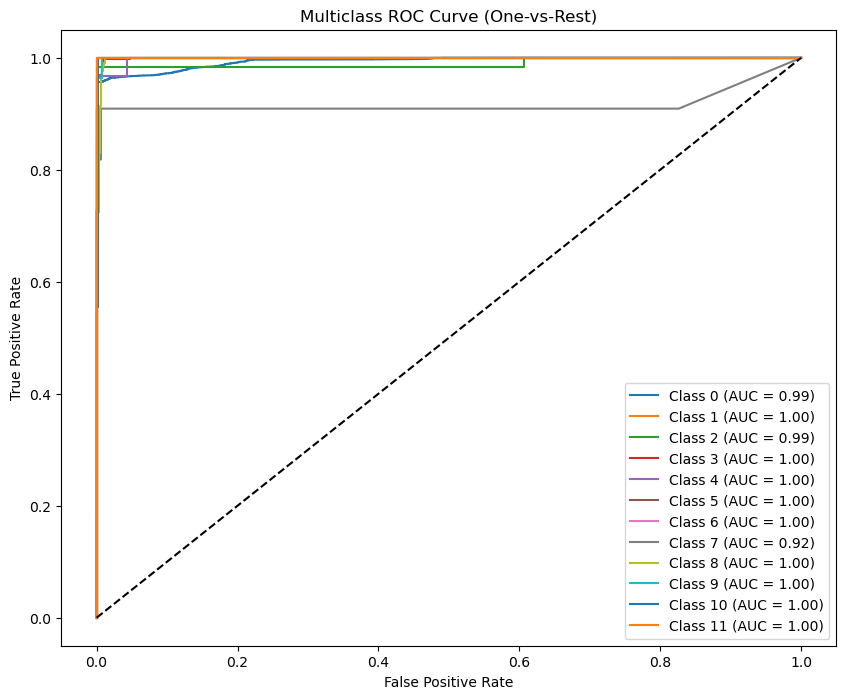

In [65]:
# -----------------------------
# Evaluate on validation set
# -----------------------------

model.eval()
with torch.no_grad():
    y_val_pred_probs = model(torch.tensor(X_val, dtype=torch.float32))
    y_val_pred = torch.argmax(y_val_pred_probs, 1)

y_val_true = y_val #y_val_tensor
y_val_pred = y_val_pred.numpy()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_val_true, y_val_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_val_true, y_val_pred)
print("\nConfusion Matrix:\n")
print(pd.DataFrame(cm, index=range(num_classes), columns=range(num_classes)))

# -----------------------------
# ROC curve (One-vs-Rest)
# -----------------------------
y_val_onehot = nn.functional.one_hot(torch.tensor(y_val), num_classes=num_classes).numpy() #y_val_tensor
y_score = nn.Softmax(dim=1)(y_val_pred_probs).numpy()

plt.figure(figsize=(10,8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_val_onehot[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# let's try a few nns

### to use a custom metric in tuner

```
# custom selection

from sklearn.metrics import f1_score, recall_score

# inside train_model after validation
y_true = []
y_pred = []
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        y_pred.extend(preds.argmax(dim=1).cpu().numpy())
        y_true.extend(yb.cpu().numpy())

val_f1 = f1_score(y_true, y_pred, average='macro')
val_recall = recall_score(y_true, y_pred, average='macro')

# report both metrics to Ray Tune
tune.report({"val_f1": val_f1, "val_recall": val_recall})


# results: Tuner.fit() output
all_results = results.get_dataframe()  # contains metrics and configs

# set recall threshold
recall_thresh = 0.7

# filter trials where recall >= threshold
eligible = all_results[all_results['val_recall'] >= recall_thresh]

# pick trial with highest F1 among eligible
if not eligible.empty:
    best_idx = eligible['val_f1'].idxmax()
    best_trial = eligible.loc[best_idx]
    print("✅ Best trial (recall>=0.7 & max F1):")
    print(best_trial)
else:
    print("⚠️ No trials passed the recall threshold")

    
    #https://chatgpt.com/c/68ed8683-4f7c-8326-bce0-951b4e9f3b53
```

## <a id="annex" style="color: darkred; text-decoration: none;"> Annex </a>


### <a id="A" style="color: darkorange; text-decoration: none;"> A. Class Imbalance </a>
